In [1]:
pip install pandas matplotlib seaborn plotly jupyter


   ------ --------------------------------- 1/6 [uri-template]
   ------------- -------------------------- 2/6 [lark]
   ------------- -------------------------- 2/6 [lark]
   ------------- -------------------------- 2/6 [lark]
   -------------------------- ------------- 4/6 [rfc3987-syntax]
   ---------------------------------------- 6/6 [isoduration]

Note: you may need to restart the kernel to use updated packages.


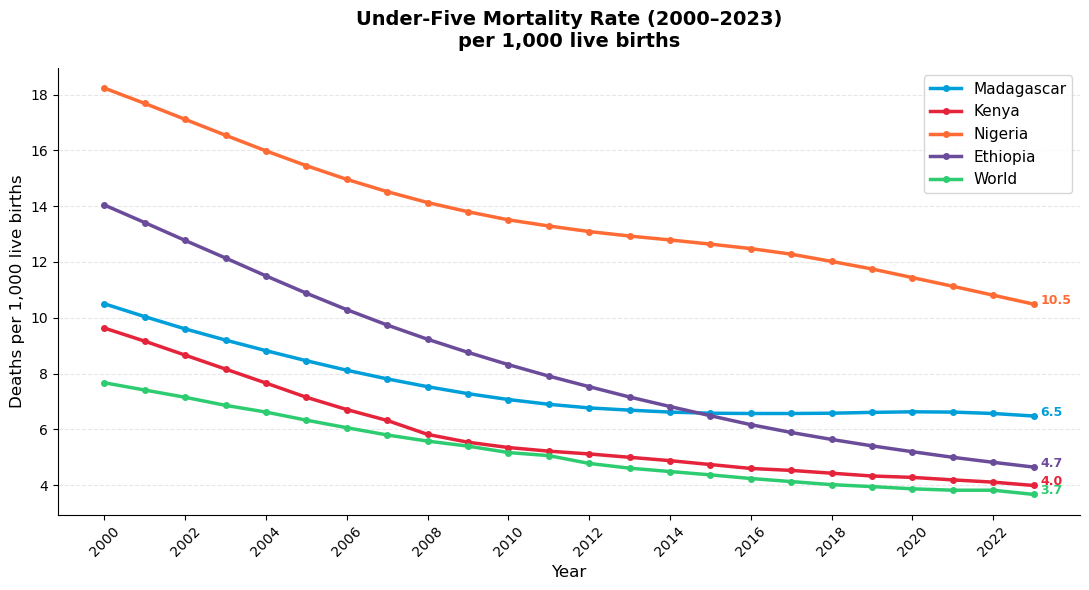

✅ Sauvegardé : visuals/child_mortality_2000_2023.png


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("visuals", exist_ok=True)

df = pd.read_csv("D:/ENI/M2/projetPerso Github/dataVisualization_Child mortality/data/child-mortality.csv")
df = df.rename(columns={"Under-five mortality rate (selected)": "Value"})

# ── Filtrer 2000 à 2023 ───────────────────────────────────────────
df = df[(df["Year"] >= 2000) & (df["Year"] <= 2023)]

pays = ["Madagascar", "Kenya", "Nigeria", "Ethiopia", "World"]
pays_dispo = [p for p in pays if p in df["Entity"].unique()]
df_filtered = df[df["Entity"].isin(pays_dispo)]

# ── Tracé ─────────────────────────────────────────────────────────
COLORS = ["#009FDA", "#E5243B", "#FF6B35", "#6B4C9A", "#2ECC71"]

fig, ax = plt.subplots(figsize=(11, 6))
for i, pays_name in enumerate(pays_dispo):
    d = df_filtered[df_filtered["Entity"] == pays_name].sort_values("Year")
    ax.plot(d["Year"], d["Value"], marker="o", markersize=4,
            linewidth=2.5, color=COLORS[i], label=pays_name)
    # Annoter la valeur finale à droite
    last = d.iloc[-1]
    ax.annotate(f"{last['Value']:.1f}",
                xy=(last["Year"], last["Value"]),
                xytext=(5, 0), textcoords="offset points",
                fontsize=9, color=COLORS[i], fontweight="bold")

ax.set_title("Under-Five Mortality Rate (2000–2023)\nper 1,000 live births",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Deaths per 1,000 live births", fontsize=12)
ax.set_xticks(range(2000, 2024, 2))
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("visuals/child_mortality_2000_2023.png", dpi=150)
plt.show()
print("✅ Sauvegardé : visuals/child_mortality_2000_2023.png")